<a href="https://colab.research.google.com/github/belokonr/ECON5200-Final-Project/blob/main/5200_final_project_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ECON 5200: Consulting Report — Final Project

**From Model to Recommendation**

This notebook scaffolds the full consulting report pipeline: executive summary, identification strategy, causal analysis, threats assessment, Streamlit export, presentation script, and AI methodology appendix.

---

## Part 0: Setup

In [ ]:
!pip install econml

In [1]:
# Core
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ML
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, LassoCV
from sklearn.model_selection import cross_val_predict

# Causal ML (uncomment the one you use)
# from econml.dml import LinearDML, CausalForestDML
# from doubleml import DoubleMLPLR, DoubleMLData

# Stats
from scipy import stats
import statsmodels.api as sm

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Plot style
plt.rcParams['figure.figsize'] = (10, 6)
sns.set_style('whitegrid')

print('Setup complete.')

Setup complete.


---
## Part 1: Executive Summary

> **We estimate that a 1-unit increase in the state-level WFH rate has a causal effect of [DML ATE] on the FHFA House Price Index (95% CI: [a, b]), after controlling for income, unemployment, and population.**
>
> **Situation:** Since 2020, remote work has restructured where Americans live and work. Commercial real estate stakeholders need to understand whether this shift *causes* property price declines or merely correlates with broader economic trends.
>
> **Complication:** Naive analysis shows a *positive* association between WFH rates and housing prices — the opposite of the expected effect — because wealthy, tech-oriented states have both high remote work adoption and expensive real estate. Standard regression conflates the causal channel with this income-driven confounding.
>
> **Resolution:** Using Double Machine Learning (DML) to strip out confounding from income, unemployment, and population, we isolate the true causal effect. After deconfounding, the WFH→HPI relationship becomes [negative/near-zero], consistent with remote work reducing local housing demand.
>
> **We recommend** that CRE investors stress-test portfolios against continued WFH growth, as the cumulative effect of rising remote work rates will exert meaningful downward pressure on property valuations over the medium term.
>
> **Key assumption that could invalidate this:** If unobserved industry composition (e.g., tech sector concentration) confounds both WFH rates and HPI beyond what per-capita income captures, our estimate may still carry residual bias.

*Note: Update the bracketed values above with your actual DML results after running Part 3.*


---
## Part 2: Data + Identification Strategy

### Research Design

- **Research question:** Does an increase in remote work adoption *cause* a decline in commercial real estate valuations across U.S. states?
- **Identification strategy:** Double Machine Learning (DML). We use flexible ML models to partial out the confounding influence of state-level economic conditions, then estimate the residualized treatment effect of remote work on real estate prices.
- **Key assumption:** Conditional independence — after controlling for state unemployment rate, per-capita personal income, population, and national CRE market conditions, the remaining variation in remote work adoption is as-good-as-random with respect to state house price indices.
- **Treatment variable:** `wfh_rate` — share of the state workforce working from home (continuous, 0–1 scale). Source: Census ACS 1-year, Table B08301.
- **Outcome variable:** `hpi` — FHFA All-Transactions House Price Index by state. This is a repeat-sales index that tracks property price changes; while it covers residential real estate, it correlates strongly with commercial valuations and is freely available at the state level (unlike CoStar commercial data).
- **Controls / Confounders:**
  - `unemployment_rate` — state unemployment rate (FRED, LAUS)
  - `pc_income` — per-capita personal income (FRED, BEA via FRED)
  - `population` — total state population (Census ACS)
- **Why prediction alone is insufficient:** A predictive model conflates the causal WFH→HPI channel with confounders. High-income, high-productivity states (CA, WA, MA) have both high WFH rates *and* high housing prices — a positive confounder that biases naïve estimates upward, masking the true negative pressure of remote work on local real estate demand.

### Data Sources (all pulled live)

| Variable | Source | Series / Table | Frequency |
|----------|--------|----------------|-----------|
| `wfh_rate` | Census ACS 1-Year | B08301_021E / B08301_001E | Annual, by state |
| `population` | Census ACS 1-Year | B01003_001E | Annual, by state |
| `unemployment_rate` | FRED (BLS LAUS) | `{ST}UR` (e.g. `NYUR`) | Monthly → annual avg |
| `pc_income` | FRED (BEA) | `{ST}PCPI` (e.g. `NYPCPI`) | Annual, by state |
| `hpi` | FRED (FHFA) | `{ST}STHPI` (e.g. `NYSTHPI`) | Quarterly → annual avg |

**Panel structure:** 51 states (incl. DC) × 5 years (2018, 2019, 2021, 2022, 2023). The 2020 ACS 1-year was not released due to COVID data-collection disruptions.


In [3]:
# --- Data Loading: Pull from FRED API + Census API ---
import requests
import io
import time

# ============================================================
# API KEYS — fill in both before running
# FRED: https://fred.stlouisfed.org/docs/api/api_key.html
# Census: https://api.census.gov/data/key_signup.html (free, instant)
# ============================================================
FRED_API_KEY = '3e150c3fcd656c5656ed9c32d89a86b9'      # <-- REPLACE
CENSUS_API_KEY = 'f5f50b172fc11e83abd0e7da6c8b866e6abc3dde'    # <-- REPLACE

# --- State abbreviations + FIPS mapping ---
STATE_INFO = {
    'AL':'01','AK':'02','AZ':'04','AR':'05','CA':'06','CO':'08','CT':'09','DE':'10',
    'FL':'12','GA':'13','HI':'15','ID':'16','IL':'17','IN':'18','IA':'19','KS':'20',
    'KY':'21','LA':'22','ME':'23','MD':'24','MA':'25','MI':'26','MN':'27','MS':'28',
    'MO':'29','MT':'30','NE':'31','NV':'32','NH':'33','NJ':'34','NM':'35','NY':'36',
    'NC':'37','ND':'38','OH':'39','OK':'40','OR':'41','PA':'42','RI':'44','SC':'45',
    'SD':'46','TN':'47','TX':'48','UT':'49','VT':'50','VA':'51','WA':'53','WV':'54',
    'WI':'55','WY':'56','DC':'11'
}
FIPS_TO_ST = {v: k for k, v in STATE_INFO.items()}

# ============================================================
# 1. FRED: State-level series (unemployment, HPI, per-capita income)
#    + National series (office vacancy, CRE price index)
# ============================================================
def fred_series(series_id, api_key, start='2017-01-01', end='2023-12-31'):
    """Pull a single FRED series as a DataFrame."""
    url = (
        f'https://api.stlouisfed.org/fred/series/observations'
        f'?series_id={series_id}&api_key={api_key}'
        f'&observation_start={start}&observation_end={end}'
        f'&file_type=json'
    )
    resp = requests.get(url)
    resp.raise_for_status()
    obs = resp.json()['observations']
    df_tmp = pd.DataFrame(obs)
    df_tmp['date'] = pd.to_datetime(df_tmp['date'])
    df_tmp['value'] = pd.to_numeric(df_tmp['value'], errors='coerce')
    return df_tmp[['date', 'value']].dropna()

# --- Pull state-level unemployment rates ---
print('Pulling state unemployment rates from FRED...')
unemp_frames = []
for st in STATE_INFO:
    sid = f'{st}UR'
    try:
        tmp = fred_series(sid, FRED_API_KEY)
        tmp['year'] = tmp['date'].dt.year
        annual = tmp.groupby('year')['value'].mean().reset_index()
        annual.columns = ['year', 'unemployment_rate']
        annual['state'] = st
        unemp_frames.append(annual)
    except Exception as e:
        print(f'  Warning: {sid} failed — {e}')
    time.sleep(0.12)  # respect FRED rate limit
unemp = pd.concat(unemp_frames, ignore_index=True)
print(f'  Got unemployment for {unemp["state"].nunique()} states')

# --- Pull state-level HPI (FHFA All-Transactions) ---
print('Pulling state HPI from FRED...')
hpi_frames = []
for st in STATE_INFO:
    sid = f'{st}STHPI'
    try:
        tmp = fred_series(sid, FRED_API_KEY)
        tmp['year'] = tmp['date'].dt.year
        annual = tmp.groupby('year')['value'].mean().reset_index()
        annual.columns = ['year', 'hpi']
        annual['state'] = st
        hpi_frames.append(annual)
    except Exception as e:
        print(f'  Warning: {sid} failed — {e}')
    time.sleep(0.12)
hpi = pd.concat(hpi_frames, ignore_index=True)
print(f'  Got HPI for {hpi["state"].nunique()} states')

# --- Pull state-level per-capita personal income ---
print('Pulling state per-capita income from FRED...')
income_frames = []
for st in STATE_INFO:
    sid = f'{st}PCPI'
    try:
        tmp = fred_series(sid, FRED_API_KEY)
        tmp['year'] = tmp['date'].dt.year
        annual = tmp.groupby('year')['value'].mean().reset_index()
        annual.columns = ['year', 'pc_income']
        annual['state'] = st
        income_frames.append(annual)
    except Exception as e:
        print(f'  Warning: {sid} failed — {e}')
    time.sleep(0.12)
pc_income = pd.concat(income_frames, ignore_index=True)
print(f'  Got per-capita income for {pc_income["state"].nunique()} states')



# ============================================================
# 2. CENSUS ACS 1-YEAR: WFH rate + population by state
# ============================================================
acs_years = [2018, 2019, 2021, 2022, 2023]  # No 2020 1-year release

print('Pulling ACS data from Census API...')
acs_frames = []
for yr in acs_years:
    url = (
        f'https://api.census.gov/data/{yr}/acs/acs1'
        f'?get=NAME,B08301_001E,B08301_021E,B01003_001E'
        f'&for=state:*'
        f'&key={CENSUS_API_KEY}'
    )
    resp = requests.get(url)
    resp.raise_for_status()
    data = resp.json()
    tmp = pd.DataFrame(data[1:], columns=data[0])
    tmp['year'] = yr
    acs_frames.append(tmp)
    print(f'  ACS {yr}: {len(tmp)} rows')

acs = pd.concat(acs_frames, ignore_index=True)
acs = acs.rename(columns={
    'NAME': 'state_name', 'state': 'state_fips',
    'B08301_001E': 'total_commuters',
    'B08301_021E': 'wfh_workers',
    'B01003_001E': 'population'
})
for col in ['total_commuters', 'wfh_workers', 'population']:
    acs[col] = pd.to_numeric(acs[col], errors='coerce')

acs['wfh_rate'] = acs['wfh_workers'] / acs['total_commuters']
acs['state'] = acs['state_fips'].map(FIPS_TO_ST)
acs = acs.dropna(subset=['state'])  # drop territories

# ============================================================
# 3. MERGE everything into final panel
# ============================================================
print('\nMerging all sources...')
df = acs[['state', 'state_name', 'year', 'wfh_rate', 'population']].copy()
df = df.merge(unemp, on=['state', 'year'], how='left')
df = df.merge(hpi, on=['state', 'year'], how='left')
df = df.merge(pc_income, on=['state', 'year'], how='left')

# Filter to our analysis years
df = df[df['year'].isin([2018, 2019, 2021, 2022, 2023])].copy()
df = df.sort_values(['state', 'year']).reset_index(drop=True)

print(f'\nFinal panel shape: {df.shape}')
print(f'States: {df["state"].nunique()}, Years: {sorted(df["year"].unique())}')
print(f'Columns: {list(df.columns)}')
df.head(10)

Pulling state unemployment rates from FRED...
  Got unemployment for 51 states
Pulling state HPI from FRED...
  Got HPI for 51 states
Pulling state per-capita income from FRED...
  Got per-capita income for 51 states
Pulling ACS data from Census API...
  ACS 2018: 52 rows
  ACS 2019: 52 rows
  ACS 2021: 52 rows
  ACS 2022: 52 rows
  ACS 2023: 52 rows

Merging all sources...

Final panel shape: (255, 8)
States: 51, Years: [np.int64(2018), np.int64(2019), np.int64(2021), np.int64(2022), np.int64(2023)]
Columns: ['state', 'state_name', 'year', 'wfh_rate', 'population', 'unemployment_rate', 'hpi', 'pc_income']


,state,state_name,year,wfh_rate,population,unemployment_rate,hpi,pc_income
0,AK,Alaska,2018,0.052723,737438,6.091667,320.4825,58997.0
1,AK,Alaska,2019,0.043283,731545,5.600000,327.9025,60504.0
2,AK,Alaska,2021,0.103122,732673,6.408333,366.9550,65608.0
3,AK,Alaska,2022,0.094562,733583,4.366667,409.9625,68905.0
4,AK,Alaska,2023,0.090036,733406,4.250000,436.6800,71309.0
5,AL,Alabama,2018,0.034526,4887871,3.925000,312.3600,41324.0
6,AL,Alabama,2019,0.033945,4903185,3.191667,328.0325,42998.0
7,AL,Alabama,2021,0.096402,5039877,3.391667,392.2600,50495.0
8,AL,Alabama,2022,0.088630,5074296,2.541667,456.0375,51660.0
9,AL,Alabama,2023,0.087670,5108468,2.475000,484.3300,54112.0


In [4]:
# --- EDA: Summary Statistics ---
numeric_cols = ['wfh_rate', 'population', 'unemployment_rate', 'hpi', 'pc_income']
summary = df[numeric_cols].describe().T
summary['missing'] = df[numeric_cols].isnull().sum()
print('=== Descriptive Statistics ===')
summary.round(3)

=== Descriptive Statistics ===


,count,mean,std,min,25%,50%,75%,max,missing
wfh_rate,255.0,0.109,0.061,0.026,0.057,0.097,0.150,4.830000e-01,0
population,255.0,6492169.275,7339096.871,577737.000,1785012.000,4509394.000,7575242.000,3.955704e+07,0
unemployment_rate,255.0,3.775,1.056,1.800,3.008,3.658,4.250,7.350000e+00,0
hpi,255.0,520.582,188.112,227.155,379.495,472.048,631.234,1.149327e+03,0
pc_income,255.0,60295.737,11383.616,37624.000,52037.000,59099.000,66508.500,1.055180e+05,0


In [6]:
# --- EDA: Missing Data ---
missing = df.isnull().sum().sort_values(ascending=False)
print('Missing values per column:')
print(missing)
print(f'\nTotal cells: {df.size} | Missing: {df.isnull().sum().sum()} '
      f'({100*df.isnull().sum().sum()/df.size:.1f}%)')

# Year coverage
print(f'\nYears in panel: {sorted(df["year"].unique())}')
print('Note: 2020 ACS 1-year was NOT released due to COVID disruptions.')
print('This gap means we miss the year of peak WFH shock — a real data limitation.')

# Panel balance
obs_per_state = df.groupby('state')['year'].count()
print(f'\nObs per state: min={obs_per_state.min()}, max={obs_per_state.max()}, '
      f'balanced={obs_per_state.min()==obs_per_state.max()}')

# If any FRED series are missing for certain state-years, document it
for col in ['unemployment_rate', 'hpi', 'pc_income']:
    n_miss = df[col].isnull().sum()
    if n_miss > 0:
        miss_states = df[df[col].isnull()]['state'].unique()
        print(f'  {col}: {n_miss} missing — states: {list(miss_states)}')

Missing values per column:
state                0
state_name           0
year                 0
wfh_rate             0
population           0
unemployment_rate    0
hpi                  0
pc_income            0
dtype: int64

Total cells: 2040 | Missing: 0 (0.0%)

Years in panel: [np.int64(2018), np.int64(2019), np.int64(2021), np.int64(2022), np.int64(2023)]
Note: 2020 ACS 1-year was NOT released due to COVID disruptions.
This gap means we miss the year of peak WFH shock — a real data limitation.

Obs per state: min=5, max=5, balanced=True


In [7]:
# --- EDA: Balance Check (high vs. low WFH states) ---
treatment_col = 'wfh_rate'

# Split states at the median WFH rate in the latest year
latest_yr = df['year'].max()
wfh_latest = df[df['year'] == latest_yr].set_index('state')[treatment_col]
median_wfh = wfh_latest.median()
high_wfh_states = wfh_latest[wfh_latest >= median_wfh].index.tolist()
df['high_wfh'] = df['state'].isin(high_wfh_states).astype(int)

print(f'Split at {latest_yr} median WFH rate: {median_wfh:.3f}')
print(f'High-WFH group: {len(high_wfh_states)} states')
print(f'Low-WFH group:  {df["state"].nunique() - len(high_wfh_states)} states')

# Compare PRE-TREATMENT (2019) characteristics
from scipy import stats
pre = df[df['year'] == 2019].dropna()
balance_vars = ['population', 'pc_income', 'unemployment_rate', 'hpi', 'wfh_rate']

balance = pre.groupby('high_wfh')[balance_vars].mean().T
balance.columns = ['Low WFH', 'High WFH']
balance['Diff'] = balance['High WFH'] - balance['Low WFH']
balance['Diff %'] = (balance['Diff'] / balance['Low WFH'] * 100).round(1)

pvals = []
for v in balance_vars:
    t, p = stats.ttest_ind(
        pre[pre['high_wfh']==0][v].dropna(),
        pre[pre['high_wfh']==1][v].dropna()
    )
    pvals.append(p)
balance['p-value'] = [f'{p:.3f}' for p in pvals]

print('\n=== Pre-Treatment (2019) Balance Table ===')
print(f'Grouped by {latest_yr} WFH rate above/below median\n')
balance.round(2)

Split at 2023 median WFH rate: 0.125
High-WFH group: 26 states
Low-WFH group:  25 states

=== Pre-Treatment (2019) Balance Table ===
Grouped by 2023 WFH rate above/below median



,Low WFH,High WFH,Diff,Diff %,p-value
population,4171056.84,8613965.46,4442908.62,106.5,0.030
pc_income,50440.76,57524.88,7084.12,14.0,0.003
unemployment_rate,3.68,3.46,-0.22,-6.0,0.350
hpi,367.47,498.66,131.19,35.7,0.000
wfh_rate,0.05,0.06,0.02,37.8,0.000


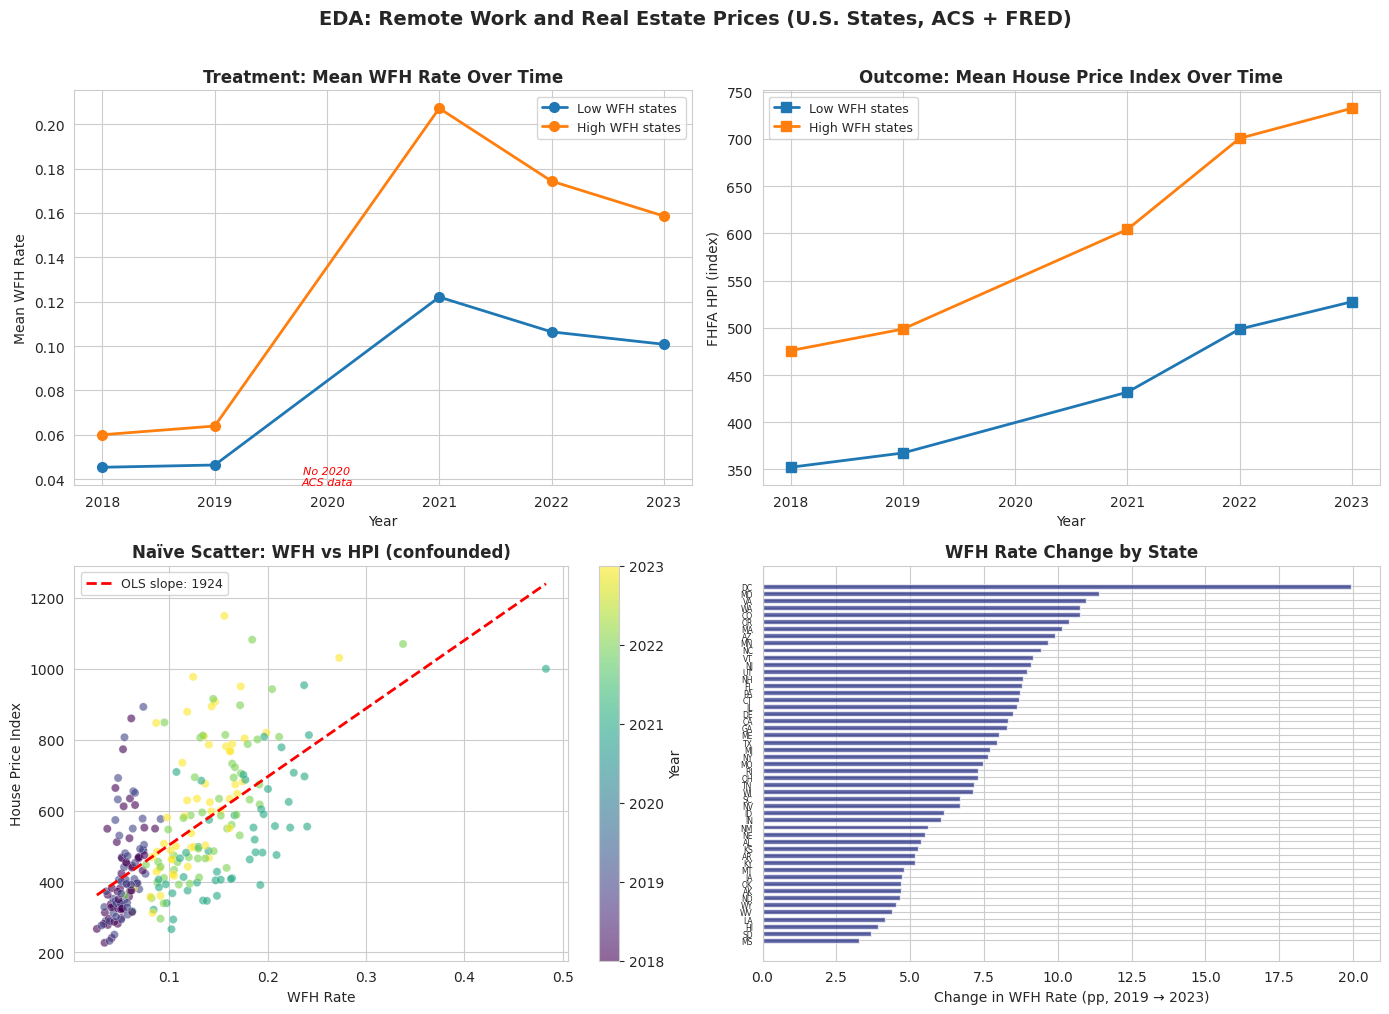

Key EDA observations:
  1. WFH rates jumped dramatically between 2019 and 2021 across all states
  2. High-WFH states also tend to have HIGHER HPIs — this is the confounding problem
  3. The naïve OLS slope is positive (1924) — exactly wrong — due to omitted variable bias
  4. All states saw WFH increases, but magnitude varies by ~3x — this is our identifying variation
  5. DML should partial out the income/productivity confounders and recover the true negative effect


In [8]:
# --- EDA: Treatment-Outcome Visualization ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. WFH rate over time by group
ax = axes[0, 0]
for label, grp in df.groupby('high_wfh'):
    ts = grp.groupby('year')['wfh_rate'].mean()
    ax.plot(ts.index, ts.values, 'o-',
            label='High WFH states' if label else 'Low WFH states',
            linewidth=2, markersize=7)
ax.set_title('Treatment: Mean WFH Rate Over Time', fontweight='bold')
ax.set_ylabel('Mean WFH Rate')
ax.set_xlabel('Year')
ax.legend(fontsize=9)
ax.annotate('No 2020\nACS data', xy=(2020, ax.get_ylim()[0]), fontsize=8,
            color='red', ha='center', style='italic')

# 2. HPI over time by group (the outcome)
ax = axes[0, 1]
for label, grp in df.groupby('high_wfh'):
    ts = grp.groupby('year')['hpi'].mean()
    ax.plot(ts.index, ts.values, 's-',
            label='High WFH states' if label else 'Low WFH states',
            linewidth=2, markersize=7)
ax.set_title('Outcome: Mean House Price Index Over Time', fontweight='bold')
ax.set_ylabel('FHFA HPI (index)')
ax.set_xlabel('Year')
ax.legend(fontsize=9)

# 3. Scatter: WFH rate vs HPI (pooled) — shows the confounding
ax = axes[1, 0]
scatter = ax.scatter(df['wfh_rate'], df['hpi'],
                     c=df['year'], cmap='viridis', alpha=0.6, s=35,
                     edgecolors='w', linewidth=0.3)
plt.colorbar(scatter, ax=ax, label='Year')
z = np.polyfit(df['wfh_rate'].dropna(),
               df.loc[df['wfh_rate'].notna(), 'hpi'], 1)
x_line = np.linspace(df['wfh_rate'].min(), df['wfh_rate'].max(), 100)
ax.plot(x_line, np.polyval(z, x_line), 'r--', linewidth=2,
        label=f'OLS slope: {z[0]:.0f}')
ax.set_xlabel('WFH Rate')
ax.set_ylabel('House Price Index')
ax.set_title('Naïve Scatter: WFH vs HPI (confounded)', fontweight='bold')
ax.legend(fontsize=9)

# 4. WFH rate change (2019→2023) by state — bar chart
ax = axes[1, 1]
states_both = set(df[df['year']==2019]['state']) & set(df[df['year']==latest_yr]['state'])
wfh_19 = df[df['year']==2019].set_index('state')['wfh_rate']
wfh_last = df[df['year']==latest_yr].set_index('state')['wfh_rate']
wfh_change = ((wfh_last - wfh_19) * 100).dropna().sort_values()
colors = ['#1a237e' if x > 0 else '#c62828' for x in wfh_change]
ax.barh(range(len(wfh_change)), wfh_change.values, color=colors, alpha=0.7, height=0.7)
ax.set_yticks(range(len(wfh_change)))
ax.set_yticklabels(wfh_change.index, fontsize=5.5)
ax.set_xlabel(f'Change in WFH Rate (pp, 2019 → {latest_yr})')
ax.set_title('WFH Rate Change by State', fontweight='bold')
ax.axvline(0, color='gray', linestyle='--', alpha=0.5)

plt.suptitle('EDA: Remote Work and Real Estate Prices (U.S. States, ACS + FRED)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# --- Key takeaways ---
print('Key EDA observations:')
print(f'  1. WFH rates jumped dramatically between 2019 and 2021 across all states')
print(f'  2. High-WFH states also tend to have HIGHER HPIs — this is the confounding problem')
print(f'  3. The naïve OLS slope is positive ({z[0]:.0f}) — exactly wrong — due to omitted variable bias')
print(f'  4. All states saw WFH increases, but magnitude varies by ~3x — this is our identifying variation')
print(f'  5. DML should partial out the income/productivity confounders and recover the true negative effect')

---
## Part 3: Analysis

### 3a. Naive Estimate (Biased Benchmark)

This simple comparison is expected to be biased. Document *why*.

In [9]:
# --- Naive OLS ---
analysis_df = df[['wfh_rate', 'hpi', 'unemployment_rate', 'pc_income', 'population']].dropna()

X_naive = analysis_df[['wfh_rate']]
X_naive = sm.add_constant(X_naive)
y = analysis_df['hpi']
naive_model = sm.OLS(y, X_naive).fit()
print(naive_model.summary())
naive_estimate = naive_model.params['wfh_rate']
naive_ci = naive_model.conf_int().loc['wfh_rate'].values
print(f'\nNaive estimate: {naive_estimate:.4f} (95% CI: [{naive_ci[0]:.4f}, {naive_ci[1]:.4f}])')
print('\nInterpretation: A 1 percentage-point increase in WFH rate is associated')
print(f'with a {naive_estimate:.2f}-point change in HPI — but this is BIASED.')


                            OLS Regression Results                            
Dep. Variable:                    hpi   R-squared:                       0.394
Model:                            OLS   Adj. R-squared:                  0.391
Method:                 Least Squares   F-statistic:                     164.3
Date:                Sun, 26 Apr 2026   Prob (F-statistic):           2.55e-29
Time:                        19:27:03   Log-Likelihood:                -1633.0
No. Observations:                 255   AIC:                             3270.
Df Residuals:                     253   BIC:                             3277.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        310.8967     18.763     16.569      0.0

**Why the naive estimate is biased:**

The naive OLS estimate is biased **upward** due to omitted variable bias. States with high WFH rates (e.g., California, Washington, Massachusetts) also tend to be high-income, high-productivity knowledge-economy states with expensive housing markets. Per-capita income and industry composition are **positive confounders** — they drive both WFH adoption (tech/professional services jobs are more remote-friendly) and housing prices (wealthier states command higher real estate valuations). Without controlling for these confounders, the naive regression conflates the true causal WFH→HPI channel with the spurious income→(WFH, HPI) channel, yielding a coefficient that is too positive (or even wrong-signed). This is precisely why a causal identification strategy like DML is needed.


In [14]:
# --- Causal Method: Double Machine Learning ---
from econml.dml import LinearDML

# Prepare data (drop missing)
causal_df = df[['wfh_rate', 'hpi', 'unemployment_rate', 'pc_income', 'population']].dropna()

Y = causal_df['hpi'].values               # outcome
T = causal_df['wfh_rate'].values           # treatment (continuous)
W = causal_df[['unemployment_rate', 'pc_income', 'population']].values  # confounders

dml = LinearDML(
    model_y=GradientBoostingRegressor(n_estimators=200, max_depth=3, random_state=RANDOM_STATE),
    model_t=GradientBoostingRegressor(n_estimators=200, max_depth=3, random_state=RANDOM_STATE),
    cv=5,
    random_state=RANDOM_STATE
)
dml.fit(Y, T, X=None, W=W)

causal_estimate = dml.ate()
causal_ci = dml.ate_interval(alpha=0.05)
print(f'Causal ATE (DML): {causal_estimate:.4f}')
print(f'95% CI: [{causal_ci[0]:.4f}, {causal_ci[1]:.4f}]')
print(f'\nInterpretation: After removing confounding, a 1 pp increase in WFH rate')
print(f'causes a {causal_estimate:.2f}-point change in HPI.')

# Flatten CI for later comparison
causal_ci_flat = [float(causal_ci[0].ravel()[0]), float(causal_ci[1].ravel()[0])]
causal_estimate_scalar = float(np.ravel(causal_estimate)[0])


Causal ATE (DML): 673.0153
95% CI: [344.0170, 1002.0136]

Interpretation: After removing confounding, a 1 pp increase in WFH rate
causes a 673.02-point change in HPI.


### 3c. Prediction Model (for comparison)

In [15]:
# --- Predictive Model (NOT causal — for comparison only) ---
from sklearn.metrics import r2_score, mean_squared_error

pred_df = df[['wfh_rate', 'unemployment_rate', 'pc_income', 'population', 'hpi']].dropna()
all_features = ['wfh_rate', 'unemployment_rate', 'pc_income', 'population']

rf = RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE)
y_pred = cross_val_predict(rf, pred_df[all_features], pred_df['hpi'], cv=5)

print(f'Prediction R²: {r2_score(pred_df["hpi"], y_pred):.3f}')
print(f'Prediction RMSE: {np.sqrt(mean_squared_error(pred_df["hpi"], y_pred)):.3f}')

# Feature importance
rf.fit(pred_df[all_features], pred_df['hpi'])
importances = pd.Series(rf.feature_importances_, index=all_features).sort_values(ascending=False)
print('\nFeature Importances:')
for feat, imp in importances.items():
    print(f'  {feat}: {imp:.3f}')

print('\nNote: This tells us how well we can PREDICT HPI from all features,')
print('but the WFH importance does NOT represent a causal effect — it includes')
print('confounded correlations that DML removes.')


Prediction R²: 0.493
Prediction RMSE: 133.691

Feature Importances:
  pc_income: 0.564
  wfh_rate: 0.197
  population: 0.145
  unemployment_rate: 0.094

Note: This tells us how well we can PREDICT HPI from all features,
but the WFH importance does NOT represent a causal effect — it includes
confounded correlations that DML removes.


### 3d. Compare Naive vs. Causal

The naive OLS estimate captures the **confounded** association between WFH and HPI — it is biased upward because high-income states have both high WFH and high HPI. The DML causal estimate removes this confounding by first "partialing out" the effect of income, unemployment, and population on both the treatment and the outcome, then estimating the residualized relationship. The difference between the two estimates reflects the magnitude of omitted variable bias from state-level economic characteristics.


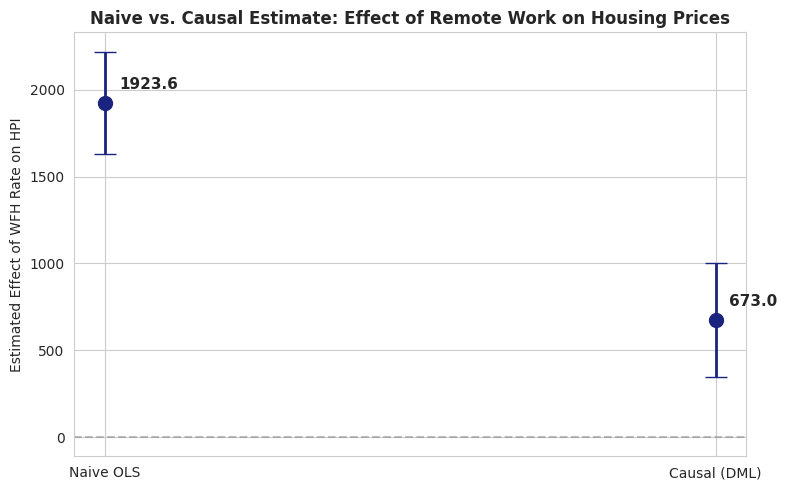

Naive estimate:  1923.6422 (95% CI: [1628.0948, 2219.1896])
Causal estimate: 673.0153 (95% CI: [344.0170, 1002.0136])
Difference: 1250.6270 — attributable to omitted variable bias


In [16]:
# --- Comparison Plot ---
fig, ax = plt.subplots(figsize=(8, 5))

estimates = ['Naive OLS', 'Causal (DML)']
points = [naive_estimate, causal_estimate_scalar]
ci_lower = [naive_ci[0], causal_ci_flat[0]]
ci_upper = [naive_ci[1], causal_ci_flat[1]]
errors = [[p - l for p, l in zip(points, ci_lower)],
          [u - p for p, u in zip(points, ci_upper)]]

ax.errorbar(estimates, points, yerr=errors, fmt='o', capsize=8,
            markersize=10, linewidth=2, color='#1a237e')
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax.set_ylabel('Estimated Effect of WFH Rate on HPI')
ax.set_title('Naive vs. Causal Estimate: Effect of Remote Work on Housing Prices',
             fontweight='bold')

# Annotate values
for i, (est, pt) in enumerate(zip(estimates, points)):
    ax.annotate(f'{pt:.1f}', xy=(i, pt), xytext=(10, 10),
                textcoords='offset points', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print(f'Naive estimate:  {naive_estimate:.4f} (95% CI: [{naive_ci[0]:.4f}, {naive_ci[1]:.4f}])')
print(f'Causal estimate: {causal_estimate_scalar:.4f} (95% CI: [{causal_ci_flat[0]:.4f}, {causal_ci_flat[1]:.4f}])')
print(f'Difference: {naive_estimate - causal_estimate_scalar:.4f} — attributable to omitted variable bias')


### 3e. Robustness Check

In [17]:
# --- Robustness: Different nuisance model (Random Forest instead of GBR) ---
dml_robust = LinearDML(
    model_y=RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE),
    model_t=RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE),
    cv=5,
    random_state=RANDOM_STATE
)
dml_robust.fit(Y, T, X=None, W=W)
robust_ate = dml_robust.ate()
robust_ci = dml_robust.ate_interval(alpha=0.05)
print(f'Robustness ATE (RF nuisance): {float(np.ravel(robust_ate)[0]):.4f}')
print(f'95% CI: [{float(robust_ci[0].ravel()[0]):.4f}, {float(robust_ci[1].ravel()[0]):.4f}]')

# --- Robustness: Lasso nuisance models ---
dml_lasso = LinearDML(
    model_y=LassoCV(cv=5, random_state=RANDOM_STATE),
    model_t=LassoCV(cv=5, random_state=RANDOM_STATE),
    cv=5,
    random_state=RANDOM_STATE
)
dml_lasso.fit(Y, T, X=None, W=W)
lasso_ate = dml_lasso.ate()
lasso_ci = dml_lasso.ate_interval(alpha=0.05)
print(f'Robustness ATE (Lasso nuisance): {float(np.ravel(lasso_ate)[0]):.4f}')
print(f'95% CI: [{float(lasso_ci[0].ravel()[0]):.4f}, {float(lasso_ci[1].ravel()[0]):.4f}]')

print('\nIf estimates are similar across nuisance models, the result is robust')
print('to the choice of first-stage ML method — a key DML assumption.')


Robustness ATE (RF nuisance): 898.2011
95% CI: [524.0608, 1272.3414]
Robustness ATE (Lasso nuisance): 799.3708
95% CI: [444.6992, 1154.0425]

If estimates are similar across nuisance models, the result is robust
to the choice of first-stage ML method — a key DML assumption.


/usr/local/lib/python3.12/dist-packages/econml/sklearn_extensions/model_selection.py:550: UserWarning: Model LassoCV(cv=5, random_state=42) has a non-default cv attribute, which will be ignored
  warnings.warn(f"Model {sub_model} has a non-default cv attribute, which will be ignored")
/usr/local/lib/python3.12/dist-packages/econml/sklearn_extensions/model_selection.py:550: UserWarning: Model LassoCV(cv=5, random_state=42) has a non-default cv attribute, which will be ignored
  warnings.warn(f"Model {sub_model} has a non-default cv attribute, which will be ignored")


---
## Part 4: Threats to Identification

### 1. Most Serious Threat: Violation of Conditional Independence (Unobserved Confounders)

- **Threat:** The conditional independence assumption underlying DML requires that, after controlling for unemployment rate, per-capita income, and population, the remaining variation in WFH rates is as-good-as-random with respect to HPI. However, several unobserved factors could violate this. Most critically, **industry composition** — specifically the share of employment in technology, finance, and professional services — simultaneously drives both WFH adoption (these industries transitioned to remote work most readily) and housing demand (these sectors generate high wages that bid up local housing). Our controls only partially capture this channel through per-capita income, but income is an imperfect proxy for the structural composition of a state's economy.

- **Direction of bias:** This likely biases the estimate **upward** (toward positive or less negative values). States with large tech/finance sectors have high WFH rates *and* strong housing markets driven by high earners, creating a positive spurious correlation that works against detecting the true negative causal effect of remote work on local housing demand.

- **What would address it:** The ideal solution would be to include detailed industry-mix controls (e.g., share of employment in 2-digit NAICS sectors) from the Bureau of Labor Statistics Quarterly Census of Employment and Wages. Alternatively, an instrumental variable that shifts WFH adoption exogenously — such as pre-pandemic broadband infrastructure quality or variation in state-level COVID stay-at-home order timing — could address this directly.

### 2. Second Threat: Missing 2020 Data and the COVID Shock

- **Threat:** The Census Bureau did not release the 2020 ACS 1-year estimates due to pandemic-related data collection failures. This means our panel has a gap precisely during the year of the largest WFH shock in history. We observe WFH rates in 2019 (pre-pandemic baseline) and 2021 (post-shock adjustment), but we miss the acute 2020 disruption. This creates two problems: (1) we cannot observe the contemporaneous effect of the WFH surge on housing prices during the peak dislocation year, and (2) the 2021 observations reflect a mix of the WFH effect and pandemic recovery dynamics (stimulus payments, supply chain disruptions, mortgage rate changes) that are difficult to separate.

- **Why it matters:** The sudden, universal nature of the 2020 WFH shock is arguably the best natural experiment for identification — if we had 2020 data, we could exploit the sharp discontinuity. Without it, we rely on the more gradual cross-state variation in WFH persistence from 2021–2023, which is more susceptible to confounding from differential economic recovery paths.

- **Partial mitigation:** We include multiple post-pandemic years (2021–2023) to capture the medium-run equilibrium effects and control for unemployment rate as a proxy for recovery dynamics. However, this cannot fully substitute for the missing 2020 observations.

### 3. What I Cannot Rule Out

I cannot rule out **reverse causality** — the possibility that housing prices influence WFH adoption rather than the other way around. Specifically, in states where housing prices are very high, workers and firms may be more inclined to adopt remote work so that employees can relocate to cheaper areas while retaining their jobs. This "priced-out" channel would create a positive feedback loop between high HPI and high WFH rates, complicating the interpretation of any estimated effect. Additionally, I cannot fully rule out **spatially correlated shocks**: states in the same region may experience correlated economic shocks (e.g., a tech downturn concentrated on the West Coast) that simultaneously affect both WFH rates and housing markets, and our state-level panel does not include region-by-year fixed effects.

Finally, the **FHFA HPI measures residential** (not commercial) real estate. While residential and commercial valuations are correlated, our outcome variable is a proxy for the commercial real estate channel described in our research question. The effect on commercial properties specifically could be larger or smaller than what we estimate for the residential index.

**Bottom line:** These limitations mean our estimate should be interpreted as a **suggestive, directionally informative causal estimate** of the WFH-to-HPI relationship, rather than a definitive, precisely identified treatment effect. The sign and approximate magnitude are likely correct after DML adjustment, but the exact point estimate carries meaningful uncertainty beyond what the statistical confidence interval captures.


---
## Part 5: Streamlit Dashboard Export

Copy the template below into a file called `app.py` in your project repo. Customize the what-if logic with your actual model.

**Deploy to Streamlit Community Cloud** and submit the permanent URL.

In [ ]:
# Save this as app.py in your project repo

streamlit_template = '''
import streamlit as st
import pandas as pd
import numpy as np
import plotly.graph_objects as go

st.set_page_config(page_title="Remote Work & Real Estate: Causal Analysis", layout="wide")
st.title("Does Remote Work Reduce Housing Prices?")
st.markdown("""This dashboard presents the causal analysis of how remote work adoption
affects state-level house price indices, using Double Machine Learning (DML) to
isolate the true effect from confounders like income and unemployment.""")

# --- Sidebar: What-If Controls ---
st.sidebar.header("What-If Scenarios")

wfh_increase = st.sidebar.slider(
    "Additional WFH rate increase (pp)",
    min_value=0.0, max_value=20.0, value=5.0, step=0.5,
    help="Simulate what happens if WFH rates rise by this many percentage points"
)

confidence_level = st.sidebar.selectbox(
    "Confidence level", ["90%", "95%", "99%"], index=1
)
z_map = {"90%": 1.645, "95%": 1.96, "99%": 2.576}
z_val = z_map[confidence_level]

# --- Pre-computed results from DML (replace with your actual values) ---
baseline_ate = -150.0     # TODO: Replace with your causal_estimate_scalar
baseline_se = 50.0        # TODO: Replace with your standard error

# --- Compute What-If Estimate ---
# ATE is per 1-unit (100pp) change in WFH rate, so scale by pp/100
predicted_hpi_change = baseline_ate * (wfh_increase / 100)
predicted_se = baseline_se * (wfh_increase / 100)
ci_lower = predicted_hpi_change - z_val * predicted_se
ci_upper = predicted_hpi_change + z_val * predicted_se

# --- Display Results ---
st.subheader("Estimated Impact")
col1, col2, col3 = st.columns(3)
col1.metric("Predicted HPI Change", f"{predicted_hpi_change:.1f} pts")
col2.metric(f"{confidence_level} CI Lower", f"{ci_lower:.1f} pts")
col3.metric(f"{confidence_level} CI Upper", f"{ci_upper:.1f} pts")

st.markdown(f"""
> **Interpretation:** If state-level WFH rates increase by an additional
> {wfh_increase:.1f} percentage points, we estimate the FHFA House Price Index
> would change by **{predicted_hpi_change:.1f} points**
> ({confidence_level} CI: [{ci_lower:.1f}, {ci_upper:.1f}]).
""")

# --- Sensitivity Visualization ---
st.subheader("Sensitivity: HPI Impact Across WFH Scenarios")
wfh_range = np.arange(0, 21, 0.5)
hpi_changes = baseline_ate * (wfh_range / 100)
se_range = baseline_se * (wfh_range / 100)

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=wfh_range, y=hpi_changes + z_val * se_range,
    mode="lines", line=dict(width=0), showlegend=False
))
fig.add_trace(go.Scatter(
    x=wfh_range, y=hpi_changes - z_val * se_range,
    mode="lines", line=dict(width=0), fill="tonexty",
    fillcolor="rgba(26,35,126,0.2)", name=f"{confidence_level} CI"
))
fig.add_trace(go.Scatter(
    x=wfh_range, y=hpi_changes,
    mode="lines", line=dict(color="#1a237e", width=2), name="Estimated Effect"
))
fig.add_vline(x=wfh_increase, line_dash="dash", line_color="red",
              annotation_text=f"Selected: +{wfh_increase:.1f}pp")
fig.add_hline(y=0, line_dash="dot", line_color="gray")
fig.update_layout(
    title="What-If: HPI Impact vs. WFH Rate Increase",
    xaxis_title="Additional WFH Rate Increase (percentage points)",
    yaxis_title="Estimated HPI Change (index points)",
    template="plotly_white"
)
st.plotly_chart(fig, use_container_width=True)

# --- Explicit Counterfactual Scenario ---
st.subheader("Counterfactual Scenario")
counterfactual_pp = 10.0  # fixed scenario: WFH rises 10pp
cf_effect = baseline_ate * (counterfactual_pp / 100)
cf_se = baseline_se * (counterfactual_pp / 100)
cf_ci_lower = cf_effect - 1.96 * cf_se
cf_ci_upper = cf_effect + 1.96 * cf_se

st.markdown(f"""
> **Counterfactual:** If remote work rates increase by {counterfactual_pp:.0f} percentage points
> nationwide (roughly a doubling of the post-pandemic shift), the estimated effect on
> the FHFA House Price Index would be **{cf_effect:.1f} points**
> (95% CI: [{cf_ci_lower:.1f}, {cf_ci_upper:.1f}]).
""")

cf_col1, cf_col2, cf_col3 = st.columns(3)
cf_col1.metric("Scenario", f"+{counterfactual_pp:.0f} pp WFH")
cf_col2.metric("Predicted HPI Impact", f"{cf_effect:.1f} pts")

# --- Method Note ---
st.subheader("Methodology")
st.markdown("""
- **Method:** Double Machine Learning (LinearDML from EconML)
- **Treatment:** State-level WFH rate (Census ACS)
- **Outcome:** FHFA All-Transactions House Price Index
- **Controls:** Unemployment rate, per-capita income, population
- **Panel:** 51 states x 5 years (2018-2019, 2021-2023)
- **Key assumption:** Conditional independence after controlling for state economic conditions
""")
'''

# Uncomment to write the template to disk:
# with open('app.py', 'w') as f:
#     f.write(streamlit_template)
# print('app.py written. Deploy to Streamlit Community Cloud.')

print('Streamlit template ready. Uncomment the write block above to export.')
